<font size=10>**TASK 1 - MULTILABEL TEXT CLASSIFICATION**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

**Question**: *How well can we classify a restaurant’s cuisine type using the content of their reviews as input?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#P1)
- [2. Data](#P2)
- [3. Multilabel Classification](#P3)
    - [3.1 Specific Data Preparation](#P3.1)
        - [3.1.1 Single-label VS Multi-label Classification](#P3.1.1)
        - [3.1.1 Similarity between restaurant categories](#P3.1.2)
        - [3.1.2 Empty Restaurant Reviews](#P3.1.3)
    - [3.2 Model Implementation](#P3.2)
    - [3.3 Model Evaluation](#P3.3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="P1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from nltk.tokenize import PunktSentenceTokenizer
sent_tokenizer = PunktSentenceTokenizer()
import plotly as px
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import ClassifierChain
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from tqdm.notebook import tqdm
from collections import defaultdict
from itertools import combinations

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *
from classification_prep import *
from modelling import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="P2"></a>
  
[Back to TOC](#toc)

In [3]:
dataset_original = load_dataset('../data/02_atlanta_restaurant_slice_2023_translated.csv')

In [4]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,longitude,num_sentences,00_before_translating_cleaning,lang_langdetect,lang_langid,needs_translation,text_translated,text_for_pipeline
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,3349,33.779814,-84.410451,3,"One word amazing!! The red fish, halibut, frie...",en,en,False,"One word amazing!! The red fish, halibut, frie...","One word amazing!! The red fish, halibut, frie..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...,False,3349,33.779814,-84.410451,1,First time here and the food is great and the ...,en,en,False,First time here and the food is great and the ...,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...,False,3349,33.779814,-84.410451,14,I recently had the pleasure of dining at Optim...,en,en,False,I recently had the pleasure of dining at Optim...,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...,False,3349,33.779814,-84.410451,9,Beautiful atmosphere and delicious food . All ...,en,en,False,Beautiful atmosphere and delicious food . All ...,Beautiful atmosphere and delicious food . All ...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...,False,3349,33.779814,-84.410451,3,We had a wonderful dinner at the Optimist . Ou...,en,en,False,We had a wonderful dinner at the Optimist . Ou...,We had a wonderful dinner at the Optimist . Ou...


In [5]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53565 entries, 0 to 53564
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   title                           53565 non-null  object 
 1   categoryName                    53565 non-null  object 
 2   website                         50599 non-null  object 
 3   url                             53565 non-null  object 
 4   reviewsCount                    53565 non-null  int64  
 5   stars                           53565 non-null  float64
 6   text                            53565 non-null  object 
 7   is_chain                        53565 non-null  bool   
 8   total_reviews_by_title          53565 non-null  int64  
 9   latitude                        53565 non-null  float64
 10  longitude                       53565 non-null  float64
 11  num_sentences                   53565 non-null  int64  
 12  00_before_translating_cleaning  

| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [6]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Multilabel Classification**</font> <a class="anchor" id="P3"></a>
  
[Back to TOC](#toc)

From the data exploration stage (Notebooks 01 and 02), several key insights emerged:

(*01_data_understtanding.ipynb*)
- The restaurant category with more restaurants its ``Mexican Restaurant`` with 8959 and at last ``Bar & grill`` with 1107 restaurants
- In our raw dataset, we observe that the **exact same review text** appears multiple times. (MultiLabel Problem)

(*02_general_data_prep.ipynb*)
- The majority of reviews in the `text` column are **short**, consisting of **1–2 sentences**. The `num_sentences` distribution supports this: 
    - median = $2$
    - $75^{th}$ percentile = $4$
    - maximum = $43$

    suggesting a few exceptionally long reviews.

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation </font> <a class="anchor" id="P3.1"></a>
  
[Back to TOC](#toc)

To achieve the best possible predictions from our models, it is essential to properly preprocess the text data. We will create different versions of the reviews using various preprocessing techniques and parameter settings to determine which approach performs best.

### <font color='#BFD72F' size=6>3.1.1 Initial Text Preprocessing: Baseline Cleaning</font> <a class="anchor" id="P3.1.1"></a>
  
[Back to TOC](#toc)

In this first step, we create a normalized version of the dataset to analyze the text structure and category similarities **before** filtering.

We apply the `main_pipeline` with the following configuration:
* **Noise Removal:** Stripping emojis, hashtags, URLs, and punctuation to reduce noise.
* **Lemmatization (`lemmatized=True`):** Converting words to their base forms (e.g., "running" $\to$ "run") to consolidate the vocabulary.
* **Stopwords Retention (`no_stopwords=False`):** We intentionally **keep** stopwords (e.g., "the", "and", "is") at this stage. This allows us to observe the natural language distribution and similarity between categories before removing grammatical connectors.

In [7]:
# Part 1
dataset['with_stopwords_cleaned_review_body'] = dataset['text_for_pipeline'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=True
    )
)

### <font color='#BFD72F' size=6>3.1.1.1 Removing empty restaurant reviews</font> <a class="anchor" id="P3.1.1.1"></a>
  
[Back to TOC](#toc)

Before proceeding with classification, we must handle "ghost" reviews—entries that became empty after our initial cleaning pipeline.
First, we analyze the `with_stopwords_cleaned_review_body` column. These are reviews where we have removed noise (URLs, emojis, special characters) but **kept** the stopwords.
* **Logic:** If a review is empty at this stage, it means the original text contained **no valid words** at all (e.g., a review containing only "!!!" or "🍔").
* **Action:** Since these rows contain zero linguistic information, we **drop them** from the dataset to prevent errors in the modeling phase.

In [8]:
empty_with_stopwords = (dataset["with_stopwords_cleaned_review_body"] == "").sum()

empty_spaces_with_stopwords = dataset["with_stopwords_cleaned_review_body"].str.strip().eq("").sum()

examples_with_stopwords = dataset[dataset["with_stopwords_cleaned_review_body"].str.strip() == ""]["with_stopwords_cleaned_review_body"].head(5)
print("Exactly empty reviews:", empty_with_stopwords)
print("Reviews with only spaces (or tabs):", empty_spaces_with_stopwords)
print("\nExamples of empty reviews:")
print(examples_with_stopwords)

Exactly empty reviews: 0
Reviews with only spaces (or tabs): 0

Examples of empty reviews:
Series([], Name: with_stopwords_cleaned_review_body, dtype: object)


In [9]:
empty_idx_with_stopwords = dataset[dataset["with_stopwords_cleaned_review_body"].str.strip() == ""].index

dataset.loc[empty_idx_with_stopwords, :]
dataset.drop(empty_idx_with_stopwords, inplace=True)
print((dataset["with_stopwords_cleaned_review_body"].str.strip() == "").sum())

0


In [10]:
category_reviews = dataset.groupby("categoryName")["with_stopwords_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(category_reviews["with_stopwords_cleaned_review_body"])

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=category_reviews["categoryName"],
    columns=category_reviews["categoryName"]
)

### <font color='#BFD72F' size=6>3.1.1.2 Category Similarity</font> <a class="anchor" id="P3.1.1.2"></a>
  
[Back to TOC](#toc)

Analyizing first the similarity of the language used in the reviews between different categories before removing stop words.

In [11]:
heatmap_chart(similarity_df,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

As observed, the great majority of categories share a very high similarity. This indicates that the language used in reviews is quite consistent across different restaurant types. 

This high overlap is largely **due to the presence of stopwords and common words** (e.g., "the", "no", "it", "is") that appear in everyday language regardless of the specific cuisine. If this "noise" is not treated, the model may struggle to distinguish between categories, as the unique signals for each cuisine are drowned out by common vocabulary.

### <font color='#BFD72F' size=6>3.1.2 Text Preprocessing: Removal of standard stopwords</font> <a class="anchor" id="P3.1.2"></a>
  
[Back to TOC](#toc)

Now analyzing the similarity again after removing stopwords.

In [12]:
# Part 2
dataset['without_stopwords_cleaned_review_body'] = dataset['text_for_pipeline'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=True
    )
)

Next, we examine the `without_stopwords_cleaned_review_body` column.
* **Logic:** These are reviews that were not empty initially, but became empty **after** we removed common stopwords (like "the", "was", "and").
* **Meaning:** A review ending up here implies it was composed entirely of generic grammatical words (e.g., *"It was all..."*) and lacked specific nouns or adjectives relevant to the cuisine.
* **Action:** We calculate the count of these "hollow" reviews to understand how much data might be lost or rendered non-informative by stopword filtering.

### <font color='#BFD72F' size=6>3.1.2.1 Removing empty restaurant reviews</font> <a class="anchor" id="P3.1.2.1"></a>
  
[Back to TOC](#toc)

### <font color='#BFD72F' size=6>3.1.2.2 Category Similarity</font> <a class="anchor" id="P3.1.2.2"></a>
  
[Back to TOC](#toc)

In [13]:
category_reviews_cleaned1 = dataset.groupby("categoryName")["without_stopwords_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()
tfidf_matrix1 = vectorizer.fit_transform(category_reviews_cleaned1["without_stopwords_cleaned_review_body"])

similarity_matrix_cleaned1 = cosine_similarity(tfidf_matrix1)

similarity_df_cleaned1 = pd.DataFrame(
    similarity_matrix_cleaned1,
    index=category_reviews_cleaned1["categoryName"],
    columns=category_reviews_cleaned1["categoryName"])

heatmap_chart(similarity_df_cleaned1,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

### Impact of Stopword Removal & Category Merging

**1. Reduced Similarity:**
As expected, removing stopwords and common words significantly decreased the similarity between categories. This indicates that the unique vocabulary of each cuisine becomes more pronounced when generic terms are excluded, allowing for clearer distinction between restaurant types. This confirms that stopword removal is a necessary step before classification.

**2. Handling High Overlap (American & Steakhouse):**
Upon analyzing the new correlation matrix, three specific categories still retained high similarity scores: *"New American restaurant"*, *"American restaurant"*, and *"Steak house"*. This suggests a strong linguistic overlap in how customers review these establishments. 

To address this and avoid model confusion, we decided to **merge these three distinct labels into a single category**: **"American & Steakhouse"**. For the remainder of this project (Exploration and Classification), these three will be treated as one unified class.

In [14]:
# joining the three categories into one : 'American & Steakhouse'
dataset['categoryName'] = dataset['categoryName'].replace({
    'American restaurant': 'American & Steakhouse',
    'New American restaurant': 'American & Steakhouse',
    'Steak house': 'American & Steakhouse',
    
})

In [15]:
category_reviews_cleaned2 = dataset.groupby("categoryName")["without_stopwords_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()
tfidf_matrix2 = vectorizer.fit_transform(category_reviews_cleaned2["without_stopwords_cleaned_review_body"])

similarity_matrix_cleaned2 = cosine_similarity(tfidf_matrix2)

similarity_df_cleaned2 = pd.DataFrame(
    similarity_matrix_cleaned2,
    index=category_reviews_cleaned2["categoryName"],
    columns=category_reviews_cleaned2["categoryName"])

heatmap_chart(similarity_df_cleaned2,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

### <font color='#BFD72F' size=6>3.1.2 Most frequent words by category</font> <a class="anchor" id="P3.1.4"></a>
  
[Back to TOC](#toc)

To better understand what defines each cuisine, we extract the most frequent words associated with each category.
* **Method:** We use `CountVectorizer` to generate a "Bag of Words" representation of the text.
* **Filtering:** We exclude extremely rare words (`min_df=5`) and extremely common words (`max_df=0.8`) to focus on meaningful terms.
* **Goal:** By identifying the top 15 words for each category, we can visually verify if the categories are distinct (e.g., "taco" for Mexican vs. "sushi" for Japanese) or if they are still polluted by generic terms (e.g., "good", "place").

In [16]:
vectorizer = CountVectorizer(max_df=0.8, min_df=5)

X = vectorizer.fit_transform(dataset['without_stopwords_cleaned_review_body'])
words = vectorizer.get_feature_names_out()

category_word_freq = []

for cat in dataset['categoryName'].unique():
    texts = dataset[dataset['categoryName'] == cat]['without_stopwords_cleaned_review_body']
    X_cat = vectorizer.transform(texts)
    counts = X_cat.sum(axis=0).A1
    freq = dict(zip(words, counts))
    top_words = Counter(freq).most_common(15)  # top 15 per category

    for word, count in top_words:
        category_word_freq.append({'category': cat, 'word': word, 'count': count})


df_freq = pd.DataFrame(category_word_freq)
df_freq.head(15)


,category,word,count
0,Seafood restaurant,food,1205
1,Seafood restaurant,great,820
2,Seafood restaurant,good,731
3,Seafood restaurant,service,682
4,Seafood restaurant,place,364
5,Seafood restaurant,seafood,355
6,Seafood restaurant,back,351
7,Seafood restaurant,shrimp,340
8,Seafood restaurant,time,321
9,Seafood restaurant,delicious,256


In [17]:
treemap_chart(df_freq,
              path_col = [px.Constant('Atlanta Restaurants Categories'), 'category', 'word'],
              value_col='count',
              title = 'Most frequent words per cuisine category in Atlanta restaurant reviews')

The graph reveals that generic terms such as **"food"**, **"service"** and **"good"** still dominate the top 15 words across multiple categories. 

### <font color='#BFD72F' size=6>3.1.3 Text Preprocessing: Removal of custom words</font> <a class="anchor" id="P3.1.5"></a>
  
[Back to TOC](#toc)

The high-frequency words seen above may provide little discriminatory power for the classification task, as they appear in positive reviews regardless of the cuisine. To improve model performance, it may be beneficial to **refine the stopword list** by removing these common sentiment words. This will force the model to focus on category-specific vocabulary (e.g., "sushi", "taco", "burger") rather than generic praise.

In [18]:
# Part 3 - custom stopwords
dataset['without_custom_stopwords_cleaned_review_body'] = dataset['text_for_pipeline'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=['food', 'good', 'service', 'great'],
        stopwords_tokeep=[],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=True
    )
)

In [19]:
category_reviews_cleaned3 = dataset.groupby("categoryName")["without_custom_stopwords_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()
tfidf_matrix2 = vectorizer.fit_transform(category_reviews_cleaned3["without_custom_stopwords_cleaned_review_body"])

similarity_matrix_cleaned3 = cosine_similarity(tfidf_matrix2)

similarity_df_cleaned3 = pd.DataFrame(
    similarity_matrix_cleaned3,
    index=category_reviews_cleaned3["categoryName"],
    columns=category_reviews_cleaned3["categoryName"])

heatmap_chart(similarity_df_cleaned3,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

### <font color='#BFD72F' size=6>3.1.4 Multilabel datasets</font> <a class="anchor" id="P3.1.4"></a>
  
[Back to TOC](#toc)

#### <font color='#BFD72F' size=6>3.1.4.1 With Stopwords</font> <a class="anchor" id="P3.1.4.1"></a>
  
[Back to TOC](#toc)

In [20]:
mlb_with_stopwords = (
    dataset.groupby("with_stopwords_cleaned_review_body")["categoryName"]
      .apply(lambda x: sorted(set(x)))   
      .reset_index()
      .rename(columns={"categoryName": "categories"})
)

display(mlb_with_stopwords)
mlb_with_stopwords.info()

,with_stopwords_cleaned_review_body,categories
0,!!service and ambience were great the food was...,[American & Steakhouse]
1,0 stars rat droppings on the floor in the last...,[Chinese restaurant]
2,0 stars to give one to review terrible whole e...,[Fast food restaurant]
3,0 stars would be more appropriate called and a...,[American & Steakhouse]
4,03 made rsvp for 630p arrived roughly 15 mins ...,[American & Steakhouse]
...,...,...
50346,zero stars if i could this mcdonald s claims t...,[Fast food restaurant]
50347,zero stars the food totally upset my stomach t...,[Italian restaurant]
50348,zero zero zero stars horrible horrible experie...,[American & Steakhouse]
50349,zucchini fries were banging great place,[Pizza restaurant]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50351 entries, 0 to 50350
Data columns (total 2 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   with_stopwords_cleaned_review_body  50351 non-null  object
 1   categories                          50351 non-null  object
dtypes: object(2)
memory usage: 786.9+ KB


#### <font color='#BFD72F' size=6>3.1.4.1.1 Light Dataset Exploration</font> <a class="anchor" id="P3.1.4.1"></a>
  
[Back to TOC](#toc)

In [21]:
category_counts = mlb_with_stopwords['categories'].apply(len)

count_by_n = category_counts.value_counts().sort_index()

df_plot = pd.DataFrame({
    "num_categories": count_by_n.index,
    "num_comments": count_by_n.values
})

df_plot_filtered = df_plot[df_plot["num_categories"] > 1]

In [22]:
bar_chart(
    data=df_plot_filtered,
    x="num_categories",
    y="num_comments",
    title="Number of Comments with More Than 1 Category",
    labels={
        "num_categories": "Number of Categories",
        "num_comments": "Number of Comments"
    },
    top_n=len(df_plot_filtered)  # ensure all appear
)


There are 4 comments with all 17 categories assigned to them:

In [23]:
mlb_with_stopwords[mlb_with_stopwords['categories'].apply(len) == 17]

,with_stopwords_cleaned_review_body,categories
13914,good food,"[American & Steakhouse, Bar & grill, Barbecue ..."
15968,great food,"[American & Steakhouse, Bar & grill, Barbecue ..."


In [24]:
mlb_with_stopwords['categories'].apply(tuple).nunique()

331

In multi-label classification, labels are rarely independent. To visualize the relationships between different cuisine types, we construct a **Co-Occurrence Matrix**.

In [25]:
mlb_with_stopwords["categories_tuple"] = mlb_with_stopwords["categories"].apply(lambda x: tuple(sorted(x)))


all_cats = sorted({cat for cats in mlb_with_stopwords["categories"] for cat in cats})

co_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

co_counts = []


for cats in mlb_with_stopwords["categories"]:
    for c1, c2 in combinations(cats, 2):  # todas as combinações de 2
        co_matrix.loc[c1, c2] += 1
        co_matrix.loc[c2, c1] += 1

for c1 in co_matrix.index:
    for c2 in co_matrix.columns:
        if c1 < c2 and co_matrix.loc[c1, c2] > 0:
            co_counts.append((c1, c2, co_matrix.loc[c1, c2]))

# ordenar
co_counts_sorted = sorted(co_counts, key=lambda x: x[2], reverse=True)

print(co_counts_sorted[:20])  # top 20 pares
for cat in all_cats:
    co_matrix.loc[cat, cat] = 0

heatmap_chart(co_matrix,
              title="Category Co-Occurrence Matrix with stopwords",)

[('American & Steakhouse', 'Mexican restaurant', 114), ('Fast food restaurant', 'Mexican restaurant', 98), ('American & Steakhouse', 'Italian restaurant', 90), ('Italian restaurant', 'Mexican restaurant', 90), ('American & Steakhouse', 'Fast food restaurant', 82), ('Chicken restaurant', 'Mexican restaurant', 69), ('Chicken restaurant', 'Fast food restaurant', 67), ('Mexican restaurant', 'Pizza restaurant', 67), ('American & Steakhouse', 'Breakfast restaurant', 66), ('Breakfast restaurant', 'Mexican restaurant', 66), ('Chinese restaurant', 'Mexican restaurant', 64), ('Breakfast restaurant', 'Fast food restaurant', 63), ('Fast food restaurant', 'Pizza restaurant', 62), ('Mexican restaurant', 'Seafood restaurant', 62), ('American & Steakhouse', 'Seafood restaurant', 61), ('Fast food restaurant', 'Italian restaurant', 61), ('Italian restaurant', 'Pizza restaurant', 61), ('American & Steakhouse', 'Chinese restaurant', 60), ('American & Steakhouse', 'Pizza restaurant', 53), ('Chinese restaur

The resulting heatmap highlights clusters of strongly related categories.
* **Diagonal:** We set the diagonal to zero to ignore self-correlation and focus purely on cross-category relationships.
* **Key Finding:** We look for "hot spots" (high values). For example, if ``Mexican restaurant`` and ``American & Steak House`` have a high co-occurrence count, it suggests they are frequently used interchangeably or describe the same establishments, supporting the case for merging them.

**However, it was decided NOT to join them because** they represent semantically distinct cuisines types.

In [26]:
import matplotlib.pyplot as plt

# Flatten the list of categories (counts each label independently)
all_categories = mlb_with_stopwords["categories"].explode()

# Count number of reviews per category
category_counts = all_categories.value_counts()


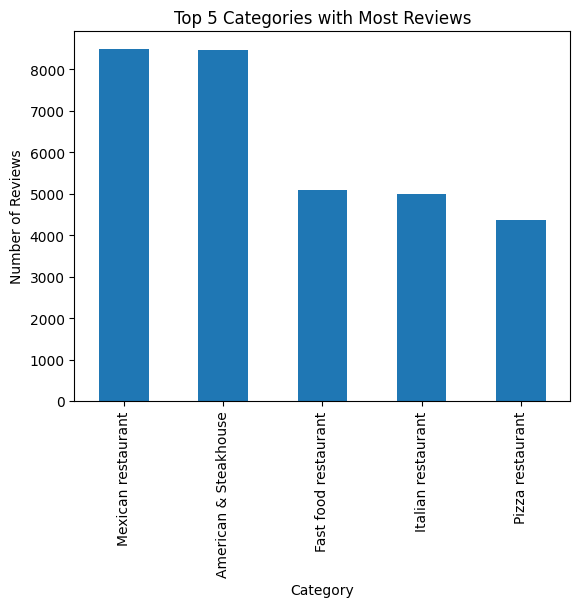

In [27]:
top_5 = category_counts.head(5)

plt.figure()
top_5.plot(kind="bar")
plt.title("Top 5 Categories with Most Reviews")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.show()

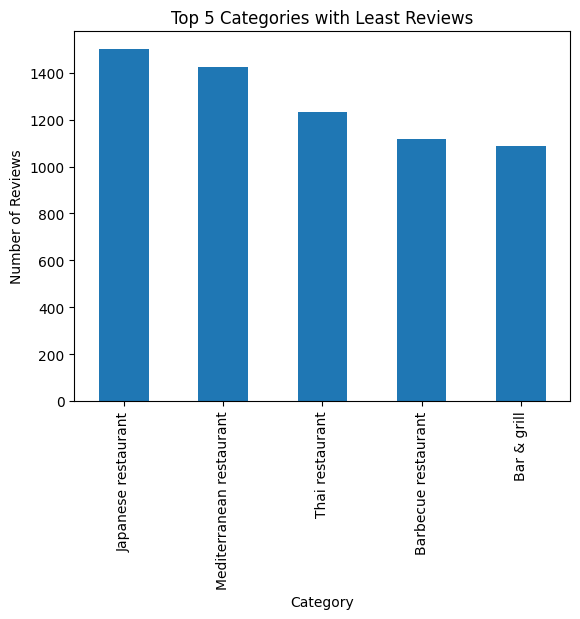

In [28]:
bottom_5 = category_counts.tail(5)

plt.figure()
bottom_5.plot(kind="bar")
plt.title("Top 5 Categories with Least Reviews")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.show()

#### <font color='#BFD72F' size=6>3.1.4.2 Without standard stopwords</font> <a class="anchor" id="P3.1.4.2"></a>
  
[Back to TOC](#toc)

In [29]:
mlb_without_s_stopwords = (
    dataset.groupby("without_stopwords_cleaned_review_body")["categoryName"]
      .apply(lambda x: sorted(set(x)))   
      .reset_index()
      .rename(columns={"categoryName": "categories"})
)

display(mlb_without_s_stopwords)
mlb_without_s_stopwords.info()

,without_stopwords_cleaned_review_body,categories
0,,"[American & Steakhouse, Chicken restaurant, Ch..."
1,!!service ambience great food good raw chicken...,[American & Steakhouse]
2,0 stars give one review terrible whole establi...,[Fast food restaurant]
3,0 stars option deserve pretty sloppy service f...,[Sandwich shop]
4,0 stars rat droppings floor last back booth ro...,[Chinese restaurant]
...,...,...
49622,zero stars thing put horrible staff including ...,[Breakfast restaurant]
49623,zero zero zero stars horrible horrible experie...,[American & Steakhouse]
49624,zing salad loved,[Chicken restaurant]
49625,zucchini fries banging great place,[Pizza restaurant]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49627 entries, 0 to 49626
Data columns (total 2 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   without_stopwords_cleaned_review_body  49627 non-null  object
 1   categories                             49627 non-null  object
dtypes: object(2)
memory usage: 775.5+ KB


In [30]:
# Count the number of exactly empty reviews
empty_without_stopwords_s = (mlb_without_s_stopwords["without_stopwords_cleaned_review_body"] == "").sum()

# Count reviews that only have spaces or tabs
empty_spaces_without_stopwords_s = mlb_without_s_stopwords["without_stopwords_cleaned_review_body"].str.strip().eq("").sum()

# Show examples (first 10)
examples_without_stopwords_s = mlb_without_s_stopwords[mlb_without_s_stopwords["without_stopwords_cleaned_review_body"].str.strip() == ""]["without_stopwords_cleaned_review_body"].head(5)

print("Exactly empty reviews:", empty_without_stopwords_s)
print("Reviews with only spaces (or tabs):", empty_spaces_without_stopwords_s)

Exactly empty reviews: 1
Reviews with only spaces (or tabs): 1


In [31]:
empty_idx_without_stopwords_s = mlb_without_s_stopwords[mlb_without_s_stopwords["without_stopwords_cleaned_review_body"].str.strip() == ""].index

#show the rows with empty cleaned reviews
dataset.loc[empty_idx_without_stopwords_s, :]

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,...,num_sentences,00_before_translating_cleaning,lang_langdetect,lang_langid,needs_translation,text_translated,text_for_pipeline,with_stopwords_cleaned_review_body,without_stopwords_cleaned_review_body,without_custom_stopwords_cleaned_review_body
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,3349,33.779814,...,3,"One word amazing!! The red fish, halibut, frie...",en,en,False,"One word amazing!! The red fish, halibut, frie...","One word amazing!! The red fish, halibut, frie...",one word amazing the red fish halibut fried ri...,one word amazing red fish halibut fried rice b...,one word amazing red fish halibut fried rice b...


In [32]:
dataset.drop(empty_idx_without_stopwords_s, inplace=True)
print((dataset["without_stopwords_cleaned_review_body"].str.strip() == "").sum())

15


### <font color='#BFD72F' size=6>3.1.4.2.1 Tozinization Without Stopwords</font> <a class="anchor" id="P3.1.4.2.1"></a>
  
[Back to TOC](#toc)

In order to facilitate further experiments with Doc2Vec vectorization in the modeling phase, we created a new preprocessed column in which the comments were tokenized. This ensures that the dataset is ready for vectorization whenever needed.

In [33]:
mlb_without_s_stopwords['without_stopwords_tokenized_cleaned_review_body'] = mlb_without_s_stopwords['without_stopwords_cleaned_review_body'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=True,
        stemmed=False,
        treat_repeated_chars=True
    )
)

#### <font color='#BFD72F' size=6>3.1.4.2.2 Light Dataset Exploration</font> <a class="anchor" id="P3.1.4.2.2"></a>
  
[Back to TOC](#toc)

In [34]:
category_counts = mlb_with_stopwords['categories'].apply(len)

count_by_n = category_counts.value_counts().sort_index()

df_plot = pd.DataFrame({
    "num_categories": count_by_n.index,
    "num_comments": count_by_n.values
})

df_plot_filtered = df_plot[df_plot["num_categories"] > 1]

In [35]:
bar_chart(
    data=df_plot_filtered,
    x="num_categories",
    y="num_comments",
    title="Number of Comments with More Than 1 Category",
    labels={
        "num_categories": "Number of Categories",
        "num_comments": "Number of Comments"
    },
    top_n=len(df_plot_filtered)  # ensure all appear
)

In [36]:
mlb_without_s_stopwords[mlb_without_s_stopwords['categories'].apply(len) == 17]

,without_stopwords_cleaned_review_body,categories,without_stopwords_tokenized_cleaned_review_body
20335,good,"[American & Steakhouse, Bar & grill, Barbecue ...",[good]
20747,good food,"[American & Steakhouse, Bar & grill, Barbecue ...","[good, food]"
23551,great food,"[American & Steakhouse, Bar & grill, Barbecue ...","[great, food]"
24063,great food great service,"[American & Steakhouse, Bar & grill, Barbecue ...","[great, food, great, service]"


In [37]:
mlb_without_s_stopwords['categories'].apply(tuple).nunique()

369

In [38]:
mlb_without_s_stopwords["categories_tuple"] = mlb_without_s_stopwords["categories"].apply(lambda x: tuple(sorted(x)))


all_cats = sorted({cat for cats in mlb_with_stopwords["categories"] for cat in cats})

co_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

co_counts = []


for cats in mlb_without_s_stopwords["categories"]:
    for c1, c2 in combinations(cats, 2):  # todas as combinações de 2
        co_matrix.loc[c1, c2] += 1
        co_matrix.loc[c2, c1] += 1

for c1 in co_matrix.index:
    for c2 in co_matrix.columns:
        if c1 < c2 and co_matrix.loc[c1, c2] > 0:
            co_counts.append((c1, c2, co_matrix.loc[c1, c2]))

# ordenar
co_counts_sorted = sorted(co_counts, key=lambda x: x[2], reverse=True)

print(co_counts_sorted[:20])  # top 20 pares
for cat in all_cats:
    co_matrix.loc[cat, cat] = 0

heatmap_chart(co_matrix,
              title="Category Co-Occurrence Matrix without standard stopwords",)

[('American & Steakhouse', 'Mexican restaurant', 136), ('Fast food restaurant', 'Mexican restaurant', 111), ('American & Steakhouse', 'Italian restaurant', 108), ('Italian restaurant', 'Mexican restaurant', 101), ('American & Steakhouse', 'Fast food restaurant', 90), ('American & Steakhouse', 'Breakfast restaurant', 79), ('Breakfast restaurant', 'Mexican restaurant', 79), ('Chinese restaurant', 'Mexican restaurant', 79), ('Chicken restaurant', 'Mexican restaurant', 73), ('Mexican restaurant', 'Seafood restaurant', 73), ('American & Steakhouse', 'Seafood restaurant', 71), ('Chicken restaurant', 'Fast food restaurant', 71), ('Italian restaurant', 'Pizza restaurant', 71), ('Mexican restaurant', 'Pizza restaurant', 71), ('Breakfast restaurant', 'Fast food restaurant', 68), ('American & Steakhouse', 'Pizza restaurant', 67), ('Fast food restaurant', 'Italian restaurant', 67), ('American & Steakhouse', 'Chinese restaurant', 65), ('Fast food restaurant', 'Pizza restaurant', 65), ('Chinese rest

#### <font color='#BFD72F' size=6>3.1.4.3 Without custom stopwords</font> <a class="anchor" id="P3.1.4.3"></a>
  
[Back to TOC](#toc)

In the dataset where we remove the custom stopwords, we will naturally have more empty comments, as a significant portion of the comments consists solely of the stopwords that are being removed. Consequently, the dataset will contain fewer comments, resulting in a smaller size and less data available for training. In the modeling section, we will evaluate whether this loss of information is justified by the model’s final performance, or if the cost outweighs the potential gains.

In [39]:
mlb_without_c_stopwords = (
    dataset.groupby("without_custom_stopwords_cleaned_review_body")["categoryName"]
      .apply(lambda x: sorted(set(x)))   
      .reset_index()
      .rename(columns={"categoryName": "categories"})
)

display(mlb_without_c_stopwords)
mlb_without_c_stopwords.info()

,without_custom_stopwords_cleaned_review_body,categories
0,,"[American & Steakhouse, Bar & grill, Barbecue ..."
1,!!service ambience raw chicken burnt potatoes ...,[American & Steakhouse]
2,0 stars give one review terrible whole establi...,[Fast food restaurant]
3,0 stars option deserve pretty sloppy quality w...,[Sandwich shop]
4,0 stars rat droppings floor last back booth ro...,[Chinese restaurant]
...,...,...
48133,zero stars totally upset stomach tonight eat c...,[Italian restaurant]
48134,zero zero zero stars horrible horrible experie...,[American & Steakhouse]
48135,zing salad loved,[Chicken restaurant]
48136,zucchini fries banging place,[Pizza restaurant]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48138 entries, 0 to 48137
Data columns (total 2 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   without_custom_stopwords_cleaned_review_body  48138 non-null  object
 1   categories                                    48138 non-null  object
dtypes: object(2)
memory usage: 752.3+ KB


In [40]:
# Count the number of exactly empty reviews
empty_without_stopwords_c = (mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"] == "").sum()

# Count reviews that only have spaces or tabs
empty_spaces_without_stopwords_c = mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"].str.strip().eq("").sum()

# Show examples (first 10)
examples_without_stopwords = mlb_without_c_stopwords[mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"].str.strip() == ""]["without_custom_stopwords_cleaned_review_body"].head(5)

print("Exactly empty reviews:", empty_without_stopwords_c)
print("Reviews with only spaces (or tabs):", empty_spaces_without_stopwords_c)

Exactly empty reviews: 1
Reviews with only spaces (or tabs): 1


In [41]:
empty_idx_without_stopwords_c = mlb_without_c_stopwords[mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"].str.strip() == ""].index

#show the rows with empty cleaned reviews
mlb_without_c_stopwords.loc[empty_idx_without_stopwords_c, :]

,without_custom_stopwords_cleaned_review_body,categories
0,,"[American & Steakhouse, Bar & grill, Barbecue ..."


In [42]:
mlb_without_c_stopwords.drop(empty_idx_without_stopwords_c, inplace=True)
print((dataset["without_stopwords_cleaned_review_body"].str.strip() == "").sum())

15


#### <font color='#BFD72F' size=6>3.1.4.3.1 Light Dataset Exploration</font> <a class="anchor" id="P3.1.4.3.1"></a>
  
[Back to TOC](#toc)

In [43]:
category_counts = mlb_without_c_stopwords['categories'].apply(len)

count_by_n = category_counts.value_counts().sort_index()

df_plot = pd.DataFrame({
    "num_categories": count_by_n.index,
    "num_comments": count_by_n.values
})

df_plot_filtered = df_plot[df_plot["num_categories"] > 1]

In [44]:
bar_chart(
    data=df_plot_filtered,
    x="num_categories",
    y="num_comments",
    title="Number of Comments with More Than 1 Category",
    labels={
        "num_categories": "Number of Categories",
        "num_comments": "Number of Comments"
    },
    top_n=len(df_plot_filtered)  # ensure all appear
)


There are 4 comments with all 17 categories assigned to them:

In [45]:
mlb_without_c_stopwords[mlb_without_c_stopwords['categories'].apply(len) == 17]

,without_custom_stopwords_cleaned_review_body,categories
11647,delicious,"[American & Steakhouse, Bar & grill, Barbecue ..."
14860,excellent,"[American & Steakhouse, Bar & grill, Barbecue ..."


In [46]:
mlb_without_c_stopwords['categories'].apply(tuple).nunique()

359

In multi-label classification, labels are rarely independent. To visualize the relationships between different cuisine types, we construct a **Co-Occurrence Matrix**.

In [47]:
mlb_without_c_stopwords["categories_tuple"] = mlb_without_c_stopwords["categories"].apply(lambda x: tuple(sorted(x)))


all_cats = sorted({cat for cats in mlb_without_c_stopwords["categories"] for cat in cats})

co_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

co_counts = []


for cats in mlb_without_c_stopwords["categories"]:
    for c1, c2 in combinations(cats, 2):  # todas as combinações de 2
        co_matrix.loc[c1, c2] += 1
        co_matrix.loc[c2, c1] += 1

for c1 in co_matrix.index:
    for c2 in co_matrix.columns:
        if c1 < c2 and co_matrix.loc[c1, c2] > 0:
            co_counts.append((c1, c2, co_matrix.loc[c1, c2]))

# ordenar
co_counts_sorted = sorted(co_counts, key=lambda x: x[2], reverse=True)

print(co_counts_sorted[:20])  # top 20 pares
for cat in all_cats:
    co_matrix.loc[cat, cat] = 0

heatmap_chart(co_matrix,
              title="Category Co-Occurrence Matrix without custom stopwords",)

[('American & Steakhouse', 'Mexican restaurant', 134), ('American & Steakhouse', 'Italian restaurant', 102), ('Italian restaurant', 'Mexican restaurant', 102), ('Fast food restaurant', 'Mexican restaurant', 101), ('American & Steakhouse', 'Fast food restaurant', 99), ('American & Steakhouse', 'Breakfast restaurant', 85), ('Chinese restaurant', 'Mexican restaurant', 83), ('Breakfast restaurant', 'Mexican restaurant', 81), ('Mexican restaurant', 'Pizza restaurant', 80), ('American & Steakhouse', 'Pizza restaurant', 74), ('Fast food restaurant', 'Pizza restaurant', 70), ('Fast food restaurant', 'Italian restaurant', 69), ('Italian restaurant', 'Pizza restaurant', 69), ('Chicken restaurant', 'Fast food restaurant', 67), ('American & Steakhouse', 'Seafood restaurant', 66), ('Breakfast restaurant', 'Fast food restaurant', 66), ('Mexican restaurant', 'Seafood restaurant', 65), ('American & Steakhouse', 'Chinese restaurant', 62), ('Breakfast restaurant', 'Italian restaurant', 61), ('Chinese re

The resulting heatmap highlights clusters of strongly related categories.
* **Diagonal:** We set the diagonal to zero to ignore self-correlation and focus purely on cross-category relationships.
* **Key Finding:** We look for "hot spots" (high values). For example, if ``Mexican restaurant`` and ``American & Steak House`` have a high co-occurrence count, it suggests they are frequently used interchangeably or describe the same establishments, supporting the case for merging them.

**However, it was decided NOT to join them because** they represent semantically distinct cuisines types.

In [48]:
import matplotlib.pyplot as plt

# Flatten the list of categories (counts each label independently)
all_categories = mlb_without_c_stopwords["categories"].explode()

# Count number of reviews per category
category_counts = all_categories.value_counts()


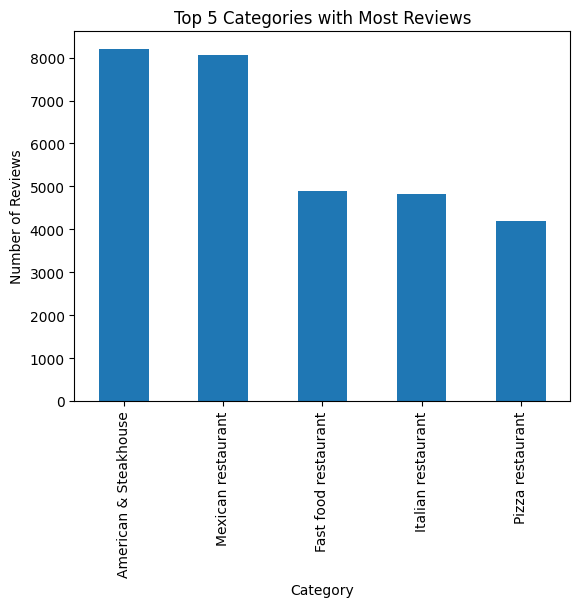

In [49]:
top_5 = category_counts.head(5)

plt.figure()
top_5.plot(kind="bar")
plt.title("Top 5 Categories with Most Reviews")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.show()

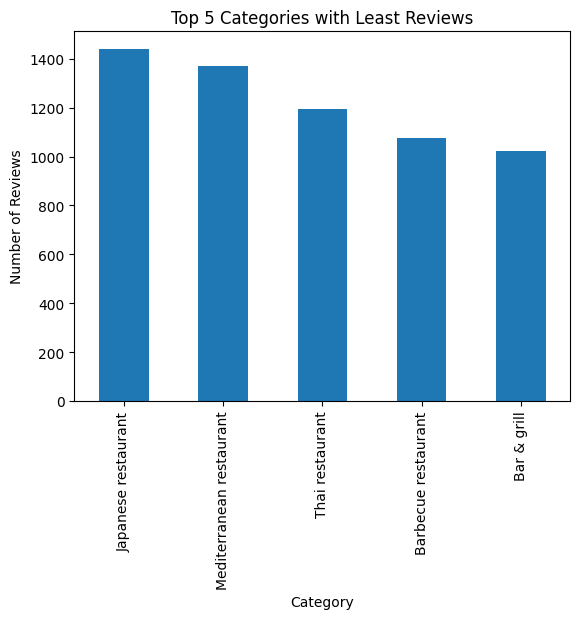

In [50]:
bottom_5 = category_counts.tail(5)

plt.figure()
bottom_5.plot(kind="bar")
plt.title("Top 5 Categories with Least Reviews")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.show()

The removal of these more general words will also result in fewer comments containing a high number of labels, yielding less general comments overall.

In [51]:
mlb_without_c_stopwords

,without_custom_stopwords_cleaned_review_body,categories,categories_tuple
1,!!service ambience raw chicken burnt potatoes ...,[American & Steakhouse],"(American & Steakhouse,)"
2,0 stars give one review terrible whole establi...,[Fast food restaurant],"(Fast food restaurant,)"
3,0 stars option deserve pretty sloppy quality w...,[Sandwich shop],"(Sandwich shop,)"
4,0 stars rat droppings floor last back booth ro...,[Chinese restaurant],"(Chinese restaurant,)"
5,0 stars would appropriate called asked speak m...,[American & Steakhouse],"(American & Steakhouse,)"
...,...,...,...
48133,zero stars totally upset stomach tonight eat c...,[Italian restaurant],"(Italian restaurant,)"
48134,zero zero zero stars horrible horrible experie...,[American & Steakhouse],"(American & Steakhouse,)"
48135,zing salad loved,[Chicken restaurant],"(Chicken restaurant,)"
48136,zucchini fries banging place,[Pizza restaurant],"(Pizza restaurant,)"


## <font color='#BFD72F' size=6>3.2 WORD CLOUDS APAGAR??</font> <a class="anchor" id="P3.2"></a>
  
[Back to TOC](#toc)

In [52]:
'''cleaned_category_texts = {}

for category in dataset["categoryName"].unique():
    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()
    combined_text = " ".join(cat_texts)

    cleaned_text = main_pipeline(
        combined_text,
        print_output=False,
        no_stopwords=True,  # keep stopwords
        stopwords_tokeep=[],
        extra_stopwords=["food","great","good","service","place",
                         "experience","delicious","staff","back","best"],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,
        no_hashtags=True,
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,
        treat_repeated_chars=True
    )

    cleaned_category_texts[category] = cleaned_text
'''

'cleaned_category_texts = {}\n\nfor category in dataset["categoryName"].unique():\n    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()\n    combined_text = " ".join(cat_texts)\n\n    cleaned_text = main_pipeline(\n        combined_text,\n        print_output=False,\n        no_stopwords=True,  # keep stopwords\n        stopwords_tokeep=[],\n        extra_stopwords=["food","great","good","service","place",\n                         "experience","delicious","staff","back","best"],\n        convert_diacritics=True,\n        lowercase=True,\n        lemmatized=True,\n        list_pos=[],\n        stemmed=False,\n        pos_tags_list=\'no_pos\',\n        tokenized_output=False,\n        no_emojis=True,\n        no_hashtags=True,\n        hashtag_retain_words=False,\n        no_newlines=True,\n        no_urls=True,\n        no_punctuation=True,\n        treat_repeated_chars=True\n    )\n\n    cleaned_category_texts[category] = cleaned_text\n'

In [53]:
'''df_low = dataset[dataset["stars"].isin([1, 2, 3])]
df_high = dataset[dataset["stars"].isin([4, 5])]


low_text = main_pipeline(
    " ".join(df_low["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
high_text = main_pipeline(
    " ".join(df_high["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
'''

'df_low = dataset[dataset["stars"].isin([1, 2, 3])]\ndf_high = dataset[dataset["stars"].isin([4, 5])]\n\n\nlow_text = main_pipeline(\n    " ".join(df_low["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\n    convert_diacritics=True,\n    lowercase=True,\n    lemmatized=True,\n    list_pos=[],\n    stemmed=False,\n    pos_tags_list=\'no_pos\',\n    tokenized_output=False,\n    no_emojis=True,\n    no_hashtags=True,\n    hashtag_retain_words=False,\n    no_newlines=True,\n    no_urls=True,\n    no_punctuation=True,\n    treat_repeated_chars=True\n)\nhigh_text = main_pipeline(\n    " ".join(df_high["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\

In [54]:
'''
low_counts = Counter(low_text.split())
high_counts = Counter(high_text.split())

word_category_map = {}

all_words = set(low_counts.keys()) | set(high_counts.keys())

for word in all_words:
    if low_counts.get(word, 0) > high_counts.get(word, 0):
        word_category_map[word] = "negative"
    elif high_counts.get(word, 0) > low_counts.get(word, 0):
        word_category_map[word] = "positive"
    else:
        word_category_map[word] = "neutral"'''



'\nlow_counts = Counter(low_text.split())\nhigh_counts = Counter(high_text.split())\n\nword_category_map = {}\n\nall_words = set(low_counts.keys()) | set(high_counts.keys())\n\nfor word in all_words:\n    if low_counts.get(word, 0) > high_counts.get(word, 0):\n        word_category_map[word] = "negative"\n    elif high_counts.get(word, 0) > low_counts.get(word, 0):\n        word_category_map[word] = "positive"\n    else:\n        word_category_map[word] = "neutral"'

In [55]:
'''def color_by_category(word, *args, **kwargs):
    category = word_category_map.get(word, "neutral")

    if category == "negative":
        return "rgb(220, 20, 60)"   # red
    elif category == "positive":
        return "rgb(34, 139, 34)"   # green
    else:
        return "rgb(120, 120, 120)" # gray'''



'def color_by_category(word, *args, **kwargs):\n    category = word_category_map.get(word, "neutral")\n\n    if category == "negative":\n        return "rgb(220, 20, 60)"   # red\n    elif category == "positive":\n        return "rgb(34, 139, 34)"   # green\n    else:\n        return "rgb(120, 120, 120)" # gray'

In [56]:
'''from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

folder_path = "../images/visualizations/wordclouds"

for category, text in cleaned_category_texts.items():

    # TF-IDF
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()

    freq_dict = dict(zip(words, vector))

    # WordCloud
    wc = WordCloud(
        width=1600,
        height=800,
        background_color="white",
        color_func=color_by_category
    ).generate_from_frequencies(freq_dict)

    wc.to_file(f"{folder_path}/wordcloud_{category.replace(' ', '_')}.png")'''



'from sklearn.feature_extraction.text import TfidfVectorizer\nfrom wordcloud import WordCloud\n\nfolder_path = "../images/visualizations/wordclouds"\n\nfor category, text in cleaned_category_texts.items():\n\n    # TF-IDF\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n\n    freq_dict = dict(zip(words, vector))\n\n    # WordCloud\n    wc = WordCloud(\n        width=1600,\n        height=800,\n        background_color="white",\n        color_func=color_by_category\n    ).generate_from_frequencies(freq_dict)\n\n    wc.to_file(f"{folder_path}/wordcloud_{category.replace(\' \', \'_\')}.png")'

In [57]:
'''# Folder to save WordCloud images
folder_path = '../images/visualizations/wordclouds'

# Generating a WordCloud for each category
for category, text in cleaned_category_texts.items():
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()
    
    tfidf_df = pd.DataFrame([vector], columns=words)
    
    wordcloud_from_vectorized(
        folder_path=folder_path,
        filename=f"wordcloud_{category.replace(' ', '_')}.png",
        vectorized_df=tfidf_df,
        top_n=100  
    )'''



'# Folder to save WordCloud images\nfolder_path = \'../images/visualizations/wordclouds\'\n\n# Generating a WordCloud for each category\nfor category, text in cleaned_category_texts.items():\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n    \n    tfidf_df = pd.DataFrame([vector], columns=words)\n    \n    wordcloud_from_vectorized(\n        folder_path=folder_path,\n        filename=f"wordcloud_{category.replace(\' \', \'_\')}.png",\n        vectorized_df=tfidf_df,\n        top_n=100  \n    )'

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="P3.2"></a>
  
[Back to TOC](#toc)

To prepare the data for modeling, we created X sets containing the review text and y sets containing the corresponding labels. The labels are binarized versions of the categories column using MultiLabelBinarizer, resulting in a binary matrix where each column represents a category and each row indicates whether the comment belongs to that category.

WITH HERMETIC CLASSIFIER IMPLEMENTATION

In [58]:
mlb = MultiLabelBinarizer()
binarised_categories = mlb.fit_transform(mlb_with_stopwords["categories"])
binarised_categories_stopwords_s = mlb.fit_transform(mlb_without_s_stopwords["categories"])
binarised_categories_stopwords_c = mlb.fit_transform(mlb_without_c_stopwords["categories"])

In [59]:
# For dataset with ALL stopwords 
X = mlb_with_stopwords["with_stopwords_cleaned_review_body"]
y = binarised_categories
y

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [60]:
# For dataset with NO standard stopwords 
X_stopwords_s = mlb_without_s_stopwords["without_stopwords_cleaned_review_body"]
y_stopwords_s = binarised_categories_stopwords_s
y_stopwords_s

array([[1, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [61]:
# For dataset with NO standard stopwords and tozenized
X_tokenized = mlb_without_s_stopwords["without_stopwords_tokenized_cleaned_review_body"]
y_tokenized = binarised_categories_stopwords_s
y_tokenized

array([[1, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [62]:
# For dataset with NO custom stopwords
X_stopwords_c = mlb_without_c_stopwords["without_custom_stopwords_cleaned_review_body"]
y_stopwords_c = binarised_categories_stopwords_c
y_stopwords_c

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [63]:
preprocessor = MainPipeline()
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
bow_vectorizer = CountVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
doc2vec_vectorizer = Doc2VecVectorizer(
    vector_size=300,
    window=8,
    min_count=2,
    epochs=40,
    dm=1,
    workers=1
)

## <font color='#BFD72F' size=6>3.2.1 Testing Models</font> <a class="anchor" id="P3.2.1"></a>
  
[Back to TOC](#toc)

In [64]:
all_datasets = {
    "Baseline (Full Text)": (X, y),
    "Standard Stopwords":   (X_stopwords_s, y_stopwords_s),
    "Custom Stopwords":     (X_stopwords_c, y_stopwords_c)
}

results = pd.DataFrame()

In [65]:
models = {
  "OvR_LogReg": OneVsRestClassifier(
        LogisticRegression(max_iter=3000)),

    "ClassifierChain_LogReg": ClassifierChain(
        LogisticRegression(max_iter=3000)),
 
 
    "OvR_LinSVC": OneVsRestClassifier(
        LinearSVC(C = 0.5, max_iter=3000)),

    "ClassifierChain_SVC": ClassifierChain(
    LinearSVC(random_state=42, max_iter=3000),
    order='random',
    random_state=42
    ),
 
    "OvR_LinearSVC_Calibrated": OneVsRestClassifier(
        CalibratedClassifierCV(
            LinearSVC(C = 0.5, max_iter=3000), cv=3)),
   
    "Dummy_ClassifierChain": ClassifierChain(
        DummyClassifier()),
 
    "Dummy_OvR": OneVsRestClassifier(
        DummyClassifier()),
 
    "OvR_SGD_LogLoss": OneVsRestClassifier(
    SGDClassifier(
        loss="log_loss",        # logistic regression
        penalty="l2",
        alpha=1e-4,
        max_iter=2000,
        class_weight="balanced",
        random_state=42)),
 
    "OvR_SGD_Hinge": OneVsRestClassifier(
    SGDClassifier(
        loss="hinge",           # SVM-style
        penalty="l2",
        alpha=1e-4,
        max_iter=2000,
        class_weight="balanced",
        random_state=42)),
 
    "OvR_LogReg_Calibrated": OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ),
        method="sigmoid",
        cv=3)),
 
    "ClassifierChain_SGD": ClassifierChain(
    SGDClassifier(
        loss="log_loss",
        max_iter=2000,
        class_weight="balanced",
        random_state=42)),
 
    "OvR_BalancedRF": OneVsRestClassifier(
        BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42)),
 
    "OvR_RandomForest": OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42))
}


In [65]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_log = run_single_model_cv(
        model_instance=models["OvR_LogReg"],
        model_name="OvR_LogReg",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_log], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_LogReg on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [01:39<00:00, 19.85s/it]


Done! OvR_LogReg [Baseline_(Full_Text)] Val F1: 0.3950
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_LogReg on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [01:29<00:00, 17.98s/it]


Done! OvR_LogReg [Standard_Stopwords] Val F1: 0.4160
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_LogReg on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [01:44<00:00, 20.93s/it]

Done! OvR_LogReg [Custom_Stopwords] Val F1: 0.4241


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755


In [66]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_cc_log = run_single_model_cv(
        model_instance=models["ClassifierChain_LogReg"],
        model_name="ClassifierChain_LogReg",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_cc_log], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: ClassifierChain_LogReg on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [01:36<00:00, 19.27s/it]


Done! ClassifierChain_LogReg [Baseline_(Full_Text)] Val F1: 0.4382
Running models for dataset: Standard Stopwords

==================== TRAINING: ClassifierChain_LogReg on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [01:11<00:00, 14.33s/it]


Done! ClassifierChain_LogReg [Standard_Stopwords] Val F1: 0.4595
Running models for dataset: Custom Stopwords

==================== TRAINING: ClassifierChain_LogReg on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [02:50<00:00, 34.06s/it]

Done! ClassifierChain_LogReg [Custom_Stopwords] Val F1: 0.4677


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.438169,0.493619,0.389901,0.692372,0.385012
4,ClassifierChain_LogReg,Standard_Stopwords,0.459542,0.518053,0.396584,0.711841,0.390533
5,ClassifierChain_LogReg,Custom_Stopwords,0.467713,0.530439,0.400035,0.720445,0.393115


In [146]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_lin = run_single_model_cv(
        model_instance=models["OvR_LinSVC"],
        model_name="OvR_LinSVC",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_lin], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_LinSVC on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [01:23<00:00, 16.63s/it]


Done! OvR_LinSVC [Baseline_(Full_Text)] Val F1: 0.4938
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_LinSVC on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:50<00:00, 10.07s/it]


Done! OvR_LinSVC [Standard_Stopwords] Val F1: 0.5076
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_LinSVC on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:41<00:00,  8.30s/it]

Done! OvR_LinSVC [Custom_Stopwords] Val F1: 0.5185


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
1,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
2,OvR_LinSVC,Custom_Stopwords,0.518540,0.649718,0.382129,0.836586,0.381079


In [147]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_lin_calibrated = run_single_model_cv(
        model_instance=models["OvR_LinearSVC_Calibrated"],
        model_name="OvR_LinearSVC_Calibrated",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_lin_calibrated], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_LinearSVC_Calibrated on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [03:00<00:00, 36.02s/it]


Done! OvR_LinearSVC_Calibrated [Baseline_(Full_Text)] Val F1: 0.5064
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_LinearSVC_Calibrated on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [02:05<00:00, 25.18s/it]


Done! OvR_LinearSVC_Calibrated [Standard_Stopwords] Val F1: 0.5168
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_LinearSVC_Calibrated on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [01:10<00:00, 14.17s/it]

Done! OvR_LinearSVC_Calibrated [Custom_Stopwords] Val F1: 0.5240


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
1,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
2,OvR_LinSVC,Custom_Stopwords,0.518540,0.649718,0.382129,0.836586,0.381079
3,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236
4,OvR_LinearSVC_Calibrated,Standard_Stopwords,0.516781,0.620307,0.379648,0.821035,0.381183
5,OvR_LinearSVC_Calibrated,Custom_Stopwords,0.523951,0.628360,0.386515,0.825556,0.387881


In [69]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_dummy_cc = run_single_model_cv(
        model_instance=models["Dummy_ClassifierChain"],
        model_name="Dummy_ClassifierChain",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_dummy_cc], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: Dummy_ClassifierChain on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:30<00:00,  6.04s/it]


Done! Dummy_ClassifierChain [Baseline_(Full_Text)] Val F1: 0.0000
Running models for dataset: Standard Stopwords

==================== TRAINING: Dummy_ClassifierChain on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:18<00:00,  3.67s/it]


Done! Dummy_ClassifierChain [Standard_Stopwords] Val F1: 0.0000
Running models for dataset: Custom Stopwords

==================== TRAINING: Dummy_ClassifierChain on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:16<00:00,  3.29s/it]

Done! Dummy_ClassifierChain [Custom_Stopwords] Val F1: 0.0000


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.438169,0.493619,0.389901,0.692372,0.385012
4,ClassifierChain_LogReg,Standard_Stopwords,0.459542,0.518053,0.396584,0.711841,0.390533
5,ClassifierChain_LogReg,Custom_Stopwords,0.467713,0.530439,0.400035,0.720445,0.393115
6,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
7,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
8,OvR_LinSVC,Custom_Stopwords,0.518032,0.647162,0.381771,0.835739,0.380636
9,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236


In [148]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_dcc_svc = run_single_model_cv(
        model_instance=models["ClassifierChain_SVC"],
        model_name="ClassifierChain_SVC",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_dcc_svc], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: ClassifierChain_SVC on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [02:37<00:00, 31.47s/it]


Done! ClassifierChain_SVC [Baseline_(Full_Text)] Val F1: 0.5289
Running models for dataset: Standard Stopwords

==================== TRAINING: ClassifierChain_SVC on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [02:36<00:00, 31.36s/it]


Done! ClassifierChain_SVC [Standard_Stopwords] Val F1: 0.5357
Running models for dataset: Custom Stopwords

==================== TRAINING: ClassifierChain_SVC on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [03:34<00:00, 42.90s/it]

Done! ClassifierChain_SVC [Custom_Stopwords] Val F1: 0.5439


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
1,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
2,OvR_LinSVC,Custom_Stopwords,0.518540,0.649718,0.382129,0.836586,0.381079
3,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236
4,OvR_LinearSVC_Calibrated,Standard_Stopwords,0.516781,0.620307,0.379648,0.821035,0.381183
5,OvR_LinearSVC_Calibrated,Custom_Stopwords,0.523951,0.628360,0.386515,0.825556,0.387881
6,ClassifierChain_SVC,Baseline_(Full_Text),0.528924,0.719883,0.435582,0.741815,0.433163
7,ClassifierChain_SVC,Standard_Stopwords,0.535702,0.741544,0.436699,0.750236,0.432910
8,ClassifierChain_SVC,Custom_Stopwords,0.543871,0.759092,0.443772,0.751166,0.439640


In [70]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_dummy_ovr = run_single_model_cv(
        model_instance=models["Dummy_OvR"],
        model_name="Dummy_OvR",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_dummy_ovr], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: Dummy_OvR on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:18<00:00,  3.75s/it]


Done! Dummy_OvR [Baseline_(Full_Text)] Val F1: 0.0000
Running models for dataset: Standard Stopwords

==================== TRAINING: Dummy_OvR on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:12<00:00,  2.53s/it]


Done! Dummy_OvR [Standard_Stopwords] Val F1: 0.0000
Running models for dataset: Custom Stopwords

==================== TRAINING: Dummy_OvR on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:11<00:00,  2.33s/it]

Done! Dummy_OvR [Custom_Stopwords] Val F1: 0.0000


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.438169,0.493619,0.389901,0.692372,0.385012
4,ClassifierChain_LogReg,Standard_Stopwords,0.459542,0.518053,0.396584,0.711841,0.390533
5,ClassifierChain_LogReg,Custom_Stopwords,0.467713,0.530439,0.400035,0.720445,0.393115
6,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
7,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
8,OvR_LinSVC,Custom_Stopwords,0.518032,0.647162,0.381771,0.835739,0.380636
9,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236


In [71]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_sgd_log = run_single_model_cv(
        model_instance=models["OvR_SGD_LogLoss"],
        model_name="OvR_SGD_LogLoss",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_sgd_log], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_SGD_LogLoss on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:37<00:00,  7.55s/it]


Done! OvR_SGD_LogLoss [Baseline_(Full_Text)] Val F1: 0.4367
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_SGD_LogLoss on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:27<00:00,  5.56s/it]


Done! OvR_SGD_LogLoss [Standard_Stopwords] Val F1: 0.4500
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_SGD_LogLoss on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:25<00:00,  5.06s/it]

Done! OvR_SGD_LogLoss [Custom_Stopwords] Val F1: 0.4605


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.438169,0.493619,0.389901,0.692372,0.385012
4,ClassifierChain_LogReg,Standard_Stopwords,0.459542,0.518053,0.396584,0.711841,0.390533
5,ClassifierChain_LogReg,Custom_Stopwords,0.467713,0.530439,0.400035,0.720445,0.393115
6,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
7,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
8,OvR_LinSVC,Custom_Stopwords,0.518032,0.647162,0.381771,0.835739,0.380636
9,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236


In [72]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_sgd_hinge = run_single_model_cv(
        model_instance=models["OvR_SGD_Hinge"],
        model_name="OvR_SGD_Hinge",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_sgd_hinge], ignore_index=True)
display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_SGD_Hinge on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:47<00:00,  9.60s/it]


Done! OvR_SGD_Hinge [Baseline_(Full_Text)] Val F1: 0.4328
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_SGD_Hinge on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:31<00:00,  6.34s/it]


Done! OvR_SGD_Hinge [Standard_Stopwords] Val F1: 0.4396
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_SGD_Hinge on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:32<00:00,  6.52s/it]

Done! OvR_SGD_Hinge [Custom_Stopwords] Val F1: 0.4501


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.438169,0.493619,0.389901,0.692372,0.385012
4,ClassifierChain_LogReg,Standard_Stopwords,0.459542,0.518053,0.396584,0.711841,0.390533
5,ClassifierChain_LogReg,Custom_Stopwords,0.467713,0.530439,0.400035,0.720445,0.393115
6,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
7,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
8,OvR_LinSVC,Custom_Stopwords,0.518032,0.647162,0.381771,0.835739,0.380636
9,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236


In [73]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_log_cal = run_single_model_cv(
        model_instance=models["OvR_LogReg_Calibrated"],
        model_name="OvR_LogReg_Calibrated",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_log_cal], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_LogReg_Calibrated on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [02:59<00:00, 35.92s/it]


Done! OvR_LogReg_Calibrated [Baseline_(Full_Text)] Val F1: 0.4390
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_LogReg_Calibrated on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [03:22<00:00, 40.58s/it]


Done! OvR_LogReg_Calibrated [Standard_Stopwords] Val F1: 0.4570
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_LogReg_Calibrated on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [02:32<00:00, 30.56s/it]

Done! OvR_LogReg_Calibrated [Custom_Stopwords] Val F1: 0.4675


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.438169,0.493619,0.389901,0.692372,0.385012
4,ClassifierChain_LogReg,Standard_Stopwords,0.459542,0.518053,0.396584,0.711841,0.390533
5,ClassifierChain_LogReg,Custom_Stopwords,0.467713,0.530439,0.400035,0.720445,0.393115
6,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
7,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
8,OvR_LinSVC,Custom_Stopwords,0.518032,0.647162,0.381771,0.835739,0.380636
9,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236


In [74]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_cc_sgd = run_single_model_cv(
        model_instance=models["ClassifierChain_SGD"],
        model_name="ClassifierChain_SGD",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )
    results = pd.concat([results, res_cc_sgd], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: ClassifierChain_SGD on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [00:57<00:00, 11.57s/it]


Done! ClassifierChain_SGD [Baseline_(Full_Text)] Val F1: 0.4063
Running models for dataset: Standard Stopwords

==================== TRAINING: ClassifierChain_SGD on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:46<00:00,  9.24s/it]


Done! ClassifierChain_SGD [Standard_Stopwords] Val F1: 0.4151
Running models for dataset: Custom Stopwords

==================== TRAINING: ClassifierChain_SGD on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [00:46<00:00,  9.37s/it]

Done! ClassifierChain_SGD [Custom_Stopwords] Val F1: 0.4189


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.438169,0.493619,0.389901,0.692372,0.385012
4,ClassifierChain_LogReg,Standard_Stopwords,0.459542,0.518053,0.396584,0.711841,0.390533
5,ClassifierChain_LogReg,Custom_Stopwords,0.467713,0.530439,0.400035,0.720445,0.393115
6,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
7,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
8,OvR_LinSVC,Custom_Stopwords,0.518032,0.647162,0.381771,0.835739,0.380636
9,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236


In [75]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_cc_bal_rf = run_single_model_cv(
        model_instance=models["OvR_BalancedRF"],
        model_name="OvR_BalancedRF",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_cc_bal_rf], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_BalancedRF on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [27:37<00:00, 331.50s/it]


Done! OvR_BalancedRF [Baseline_(Full_Text)] Val F1: 0.4376
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_BalancedRF on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [23:12<00:00, 278.56s/it]


Done! OvR_BalancedRF [Standard_Stopwords] Val F1: 0.4437
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_BalancedRF on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [30:34<00:00, 366.88s/it]

Done! OvR_BalancedRF [Custom_Stopwords] Val F1: 0.4531


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.438169,0.493619,0.389901,0.692372,0.385012
4,ClassifierChain_LogReg,Standard_Stopwords,0.459542,0.518053,0.396584,0.711841,0.390533
5,ClassifierChain_LogReg,Custom_Stopwords,0.467713,0.530439,0.400035,0.720445,0.393115
6,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
7,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
8,OvR_LinSVC,Custom_Stopwords,0.518032,0.647162,0.381771,0.835739,0.380636
9,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236


In [76]:
for data_name, (current_X, current_y) in all_datasets.items():
    print(f"Running models for dataset: {data_name}")


    res_ovr_rf = run_single_model_cv(
        model_instance=models["OvR_RandomForest"],
        model_name="OvR_RandomForest",
        X=current_X, 
        y=current_y, 
        vectorizer=tfidf_vectorizer,
        dataset_name=data_name.replace(" ", "_")
    )

    results = pd.concat([results, res_ovr_rf], ignore_index=True)

display(results)

Running models for dataset: Baseline (Full Text)

==================== TRAINING: OvR_RandomForest on Baseline_(Full_Text) ====================


Folds: 100%|██████████| 5/5 [1:06:08<00:00, 793.77s/it]


Done! OvR_RandomForest [Baseline_(Full_Text)] Val F1: 0.4336
Running models for dataset: Standard Stopwords

==================== TRAINING: OvR_RandomForest on Standard_Stopwords ====================


Folds: 100%|██████████| 5/5 [1:06:26<00:00, 797.33s/it]


Done! OvR_RandomForest [Standard_Stopwords] Val F1: 0.4801
Running models for dataset: Custom Stopwords

==================== TRAINING: OvR_RandomForest on Custom_Stopwords ====================


Folds: 100%|██████████| 5/5 [54:20<00:00, 652.00s/it]


Done! OvR_RandomForest [Custom_Stopwords] Val F1: 0.4975


,Model,Preprocessing,Val_F1,Train_F1,Val_Accuracy,Val_Precision,Val_Recall
0,OvR_LogReg,Baseline_(Full_Text),0.394959,0.432731,0.267447,0.838301,0.265003
1,OvR_LogReg,Standard_Stopwords,0.416013,0.457518,0.285248,0.841487,0.282920
2,OvR_LogReg,Custom_Stopwords,0.424097,0.466283,0.292310,0.847473,0.289755
3,ClassifierChain_LogReg,Baseline_(Full_Text),0.438169,0.493619,0.389901,0.692372,0.385012
4,ClassifierChain_LogReg,Standard_Stopwords,0.459542,0.518053,0.396584,0.711841,0.390533
5,ClassifierChain_LogReg,Custom_Stopwords,0.467713,0.530439,0.400035,0.720445,0.393115
6,OvR_LinSVC,Baseline_(Full_Text),0.493823,0.608911,0.356866,0.838056,0.355605
7,OvR_LinSVC,Standard_Stopwords,0.507569,0.634303,0.371346,0.836539,0.369627
8,OvR_LinSVC,Custom_Stopwords,0.518032,0.647162,0.381771,0.835739,0.380636
9,OvR_LinearSVC_Calibrated,Baseline_(Full_Text),0.506406,0.604783,0.368601,0.817931,0.371236


In [63]:
from tensorflow.keras.preprocessing.text import Tokenizer


tokenizer = Tokenizer()

tokenizer.fit_on_texts(X_stopwords_c)


vocab_size = len(tokenizer.word_index) + 1  

print(f"Your Vocabulary Size is: {vocab_size}")

Your Vocabulary Size is: 26129


In [64]:
# 1. Calculate length (number of words) for every review
# assuming X_stopwords_c is a pandas Series of strings
review_lengths = X_stopwords_c.apply(lambda x: len(x.split()))

# 2. Get Statistics
print("Max Length:", review_lengths.max())
print("Mean Length:", review_lengths.mean())
print("Median Length:", review_lengths.median())
print("95th Percentile:", review_lengths.quantile(0.95))


Max Length: 376
Mean Length: 17.867731682489563
Median Length: 11.0
95th Percentile: 57.0


In [64]:
import tensorflow as tf

# Force Y to be float32
y_stopwords_c = y_stopwords_c.astype('float32')

In [65]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GRU, Dropout

# Constants
VOCAB_SIZE = 26129 + 1      # Add 1 for the '0' padding token
EMBEDDING_DIM = 100         # Dimension of the dense vector
NUM_CLASSES = 17

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_stopwords_c)

sequences = tokenizer.texts_to_sequences(X_stopwords_c)

X_deep_learning = pad_sequences(sequences, maxlen=60, padding='post')

In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GRU, Dropout, Bidirectional, GlobalMaxPool1D, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

# 1. Embedding Layer with Spatial Dropout
model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=100, input_length=60))
model.add(SpatialDropout1D(0.2)) 

model.add(Bidirectional(GRU(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)))
model.add(GlobalMaxPool1D())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(17, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])

In [67]:
from sklearn.model_selection import train_test_split

X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_deep_learning, 
    y_stopwords_c, 
    test_size=0.2, 
    random_state=42
)

In [68]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,    
    patience=1,       
    min_lr=0.00001,  
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3,     
    restore_best_weights=True
)

my_callbacks = [early_stop, reduce_lr]

In [113]:
history = model.fit(
    X_train_dl, 
    y_train_dl,
    epochs=15, 
    batch_size=32, 
    validation_data=(X_val_dl, y_val_dl),
    verbose=1,
    callbacks=my_callbacks
)

Epoch 1/15
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 234s 188ms/step - binary_accuracy: 0.9407 - loss: 0.2066 - val_binary_accuracy: 0.9515 - val_loss: 0.1500 - learning_rate: 0.0010
Epoch 2/15
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 174s 144ms/step - binary_accuracy: 0.9522 - loss: 0.1518 - val_binary_accuracy: 0.9566 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 3/15
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 200s 166ms/step - binary_accuracy: 0.9576 - loss: 0.1323 - val_binary_accuracy: 0.9588 - val_loss: 0.1300 - learning_rate: 0.0010
Epoch 4/15
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - binary_accuracy: 0.9623 - loss: 0.1158
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 195s 162ms/step - binary_accuracy: 0.9621 - loss: 0.1172 - val_binary_accuracy: 0.9594 - val_loss: 0.1303 - learning_rate: 0.0010
Epoch 5/15
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - binary_accuracy: 0.9669 - loss: 0.1018
Epoch 5: ReduceLROnPlateau reducing learning rate to

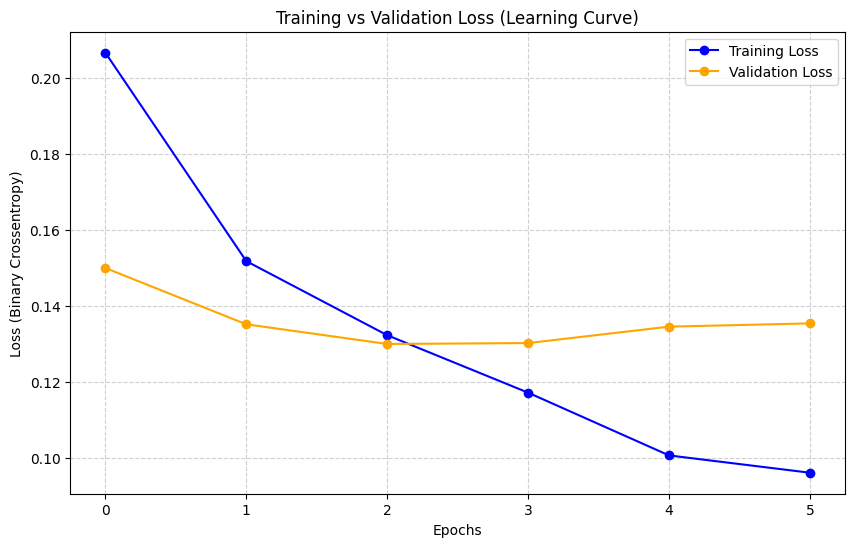

In [114]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue', marker='o')
plt.plot(val_loss, label='Validation Loss', color='orange', marker='o')

plt.title('Training vs Validation Loss (Learning Curve)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Show
plt.show()

In [115]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

train_loss = history.history['loss'][-1]
val_loss   = history.history['val_loss'][-1]

y_pred_train_proba = model.predict(X_train_dl)
y_pred_train_binary = (y_pred_train_proba > 0.5).astype(int)

y_pred_val_proba = model.predict(X_val_dl)
y_pred_val_binary = (y_pred_val_proba > 0.5).astype(int)

# 3. Calculate F1
train_f1 = f1_score(y_train_dl, y_pred_train_binary, average='weighted')
val_f1   = f1_score(y_val_dl, y_pred_val_binary, average='weighted')
val_acc  = accuracy_score(y_val_dl, y_pred_val_binary)

dl_result = pd.DataFrame([{
    "Model": "GRU_DeepLearning",
    "Preprocessing": "Custom_Stopwords (Embeddings)",
    "Train_Loss": train_loss,  
    "Val_Loss": val_loss,      
    "Train_F1": train_f1,
    "Val_F1": val_f1,
    "Val_Accuracy": val_acc
}])


display(dl_result)

results = pd.concat([results, dl_result], ignore_index=True)

1204/1204 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step
301/301 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step


,Model,Preprocessing,Train_Loss,Val_Loss,Train_F1,Val_F1,Val_Accuracy
0,GRU_DeepLearning,Custom_Stopwords (Embeddings),0.096201,0.135456,0.605359,0.525864,0.406834


NameError: name 'results' is not defined

In [73]:
import shutil
import os

# The directory causing the issue
dir_name = 'my_dir'

# Check if it exists and delete it (whether it is a file or a folder)
if os.path.exists(dir_name):
    try:
        shutil.rmtree(dir_name) # Deletes if it's a folder
        print(f"Deleted folder: {dir_name}")
    except NotADirectoryError:
        os.remove(dir_name)     # Deletes if it's a file
        print(f"Deleted conflicting file: {dir_name}")
else:
    print(f"{dir_name} does not exist yet. Safe to proceed.")

PermissionError: [WinError 5] Acesso negado: 'my_dir\\intro_to_kt'

In [71]:
max_id = np.max(X_train_dl)
print(f"Max Word ID in data: {max_id}")
print(f"Set input_dim to at least: {max_id + 1}")

Max Word ID in data: 26128
Set input_dim to at least: 26129


In [72]:
import keras_tuner as kt
import tempfile
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GRU, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# 1. Generate a temporary directory that is guaranteed to be clean
# This creates a path like C:\Users\filip\AppData\Local\Temp\tmp73829...
unique_dir = tempfile.mkdtemp()
print(f"Saving tuner results to temporary folder: {unique_dir}")

# 2. Define your Model
def build_model(hp):
    model = Sequential()
    embed_dim = hp.Choice('embedding_dim', values=[50, 100])
    model.add(Embedding(input_dim=26129, output_dim=embed_dim, input_length=60))
    model.add(SpatialDropout1D(0.2))
    
    gru_units = hp.Int('gru_units', min_value=32, max_value=128, step=32)
    model.add(Bidirectional(GRU(units=gru_units, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)))
    
    dense_units = hp.Int('dense_units', min_value=32, max_value=64, step=32)
    model.add(Dense(dense_units, activation='relu'))
    
    dropout_rate = hp.Float('dropout_rate', min_value=0.3, max_value=0.6, step=0.1)
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(17, activation='sigmoid'))
    
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=lr), metrics=['binary_accuracy'])
    return model

# 3. Initialize Tuner using the UNIQUE directory
tuner = kt.Hyperband(
    build_model,
    objective='val_binary_accuracy',
    max_epochs=10,
    factor=3,
    directory=unique_dir,       # <--- USES THE TEMP FOLDER
    project_name='tuning_run'   # No conflicts possible here
)

# 4. Search
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
print("Starting search...")

tuner.search(X_train_dl, y_train_dl, 
             epochs=10, 
             validation_data=(X_val_dl, y_val_dl), 
             callbacks=[stop_early])

# 5. Get Results
best_hps = tuner.get_best_hyperparameters(num_models=1)[0]
print(f"Best GRU Units: {best_hps.get('gru_units')}")

Trial 30 Complete [00h 11m 36s]
val_binary_accuracy: 0.9585098624229431

Best val_binary_accuracy So Far: 0.9588826298713684
Total elapsed time: 04h 54m 58s


TypeError: BaseTuner.get_best_hyperparameters() got an unexpected keyword argument 'num_models'

In [73]:
from sklearn.metrics import f1_score, classification_report
import numpy as np


best_model = tuner.get_best_models(num_models=1)[0]


print("Generating predictions with the best model...")
y_train_probs = best_model.predict(X_train_dl)
y_val_probs = best_model.predict(X_val_dl)


y_train_pred = (y_train_probs > 0.5).astype(int)
y_val_pred = (y_val_probs > 0.5).astype(int)

train_f1 = f1_score(y_train_dl, y_train_pred, average='micro')
val_f1 = f1_score(y_val_dl, y_val_pred, average='micro')

print("-" * 30)
print(f"🏆 BEST MODEL RESULTS")
print("-" * 30)
print(f"Train F1 Score: {train_f1:.4f}")
print(f"Val   F1 Score: {val_f1:.4f}")
print("-" * 30)

print("\nDetailed Validation Report:")
print(classification_report(y_val_dl, y_val_pred))

Generating predictions with the best model...
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step
301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
------------------------------
🏆 BEST MODEL RESULTS
------------------------------
Train F1 Score: 0.6704
Val   F1 Score: 0.5583
------------------------------

Detailed Validation Report:
              precision    recall  f1-score   support

           0       0.72      0.41      0.52      1645
           1       0.00      0.00      0.00       204
           2       0.83      0.46      0.59       209
           3       0.65      0.31      0.42       460
           4       0.89      0.16      0.26       315
           5       0.88      0.32      0.47       447
           6       0.72      0.41      0.52       983
           7       0.70      0.51      0.59       366
           8       0.98      0.56      0.72       315
           9       0.80      0.42      0.56       972
          10       0.91      0.43      0.58       321
          11       0.97      

## <font color='#BFD72F' size=6>3.2.2 Fine Tunning the Model - GridSearch</font> <a class="anchor" id="P3.2.2"></a>
  
[Back to TOC](#toc)

#### <font color='#BFD72F' size=6>3.2.2.1 Base Line - GridSearch</font> <a class="anchor" id="P3.1.4.3.1"></a>
  
[Back to TOC](#toc)

In [77]:
classifier = 

SyntaxError: invalid syntax (724150109.py, line 1)

In [ ]:
hermetic_classifier = HermeticClassifier(preprocessor, tfidf_vectorizer, classifier)

In [ ]:
hermetic_classifier.fit(X,y)

In [ ]:
hermetic_classifier.get_params(deep=True)

In [ ]:
param_grid = {
    'vectorizer__max_features': [None],
    'vectorizer__ngram_range': [(1, 1)],    
    'classifier__estimator__C': [0.5, 0.8, 1, 2],
    'classifier__estimator__class_weight': [None],
    'classifier__estimator__loss': ['hinge', 'squared_hinge']
}
 
 


In [ ]:
scores = ["accuracy","precision_weighted","recall_weighted","f1_weighted"]
 
grid_search = GridSearchCV(
    estimator=hermetic_classifier,
    param_grid=param_grid,
    scoring=scores,
    cv=MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=3,
    n_jobs = 1,
    error_score='raise',
    refit="f1_weighted",
    return_train_score=True
)
grid_result = grid_search.fit(X, y)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.6min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.0min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.9min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.5min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.1min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__

KeyboardInterrupt: 

In [ ]:
print("Best estimator:", grid_result.best_estimator_)
print("Best params:", grid_result.best_params_)
print("Best score:", grid_result.best_score_)

Best params: {'classifier__estimator__C': 10, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__penalty': 'l2', 'classifier__estimator__random_state': 1, 'classifier__estimator__solver': 'lbfgs', 'd2v_vector_size': 300, 'd2v_window': 20, 'preprocessor__custom_stopwords': ['food', 'great', 'good', 'service', 'place', 'experience', 'delicious', 'staff', 'back', 'best'], 'preprocessor__lemmatized': True, 'preprocessor__lowercase': True, 'preprocessor__no_stopwords': True, 'vectorizer': TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b')}
Best score: 0.4843955022694117


#### <font color='#BFD72F' size=6>3.2.2.2 Without Standard Stopwords - GridSearch</font> <a class="anchor" id="P3.1.4.3.1"></a>
  
[Back to TOC](#toc)

In [ ]:
classifier2= 

In [ ]:
hermetic_classifier_s = HermeticClassifier(preprocessor, tfidf_vectorizer, classifier2)

In [ ]:
hermetic_classifier_s.fit(X,y)

In [ ]:
hermetic_classifier_s.get_params(deep=True)

In [ ]:
param_grid_s = {
    'vectorizer__max_features': [None],
    'vectorizer__ngram_range': [(1, 1)],    
    'classifier__estimator__estimator__C': [0.8, 1, 2],
    'classifier__estimator__estimator__loss': ['hinge'],
    'classifier__estimator__method': ['sigmoid', 'isotonic']}

In [ ]:
scores = ["accuracy","precision_weighted","recall_weighted","f1_weighted"]

grid_search_s = GridSearchCV(
    estimator=hermetic_classifier_s,
    param_grid=param_grid_s,
    scoring=scores,
    cv=MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=3,
    n_jobs = 1,
    error_score='raise',
    refit="f1_weighted",
    return_train_score=True
)
grid_result_s = grid_search_s.fit(X, y)

In [ ]:
print("Best params:", grid_result2.best_params_)
print("Best score:", grid_result.best_score_)
print("Best score:", grid_result2.best_estimator_)

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
 
# 1. Setup
best_internal_classifier = grid_result.best_estimator_.classifier
dummy_preprocessor = IdentityPreprocessor()
 
rows_categories = []
rows_global = []
 
print(f"Running full analysis on: {type(best_internal_classifier).__name__}...")
 
# 2. Iterate Folds
for fold, (train_idx, test_idx) in enumerate(mskf.split(X, y), start=1):
   
    # --- Split ---
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    if hasattr(y, "iloc"):
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else:
        y_train, y_test = y[train_idx], y[test_idx]
 
    # --- Hermetic Wrapper ---
    hermetic_model = HermeticClassifier(
        preprocessor=dummy_preprocessor,
        vectorizer=tfidf_vectorizer,
        classifier=best_internal_classifier
    )
 
    # --- Fit & Predict ---
    hermetic_model.fit(X_train, y_train)
    y_val_pred = hermetic_model.predict(X_test)
    y_train_pred = hermetic_model.predict(X_train)
 
    # --- Metrics ---
    val_accuracy = accuracy_score(y_test, y_val_pred)
   
    val_report = classification_report(
        y_test, y_val_pred, target_names=mlb.classes_, zero_division=0, output_dict=True
    )
    train_report = classification_report(
        y_train, y_train_pred, target_names=mlb.classes_, zero_division=0, output_dict=True
    )
 
    for label in mlb.classes_:
        rows_categories.append({
            "Category": label,
            "Train_F1": train_report[label]["f1-score"],
            "Val_F1": val_report[label]["f1-score"],
            "Val_Precision": val_report[label]["precision"],
            "Val_Recall": val_report[label]["recall"],
            "Support": val_report[label]["support"]
        })

    rows_global.append({
        "Fold": fold,
        "Val_Accuracy": val_accuracy,
        "Val_Weighted_Precision": val_report["weighted avg"]["precision"],
        "Val_Weighted_Recall": val_report["weighted avg"]["recall"],
        "Val_Weighted_F1": val_report["weighted avg"]["f1-score"],
        "Train_Weighted_F1": train_report["weighted avg"]["f1-score"]
    })

# --- Global Table ---
df_global = pd.DataFrame(rows_global)
global_avg = df_global.mean().to_frame(name="Average Score").T.drop(columns=["Fold"])
 
cols_order = ["Train_Weighted_F1", "Val_Weighted_F1", "Val_Weighted_Precision", "Val_Weighted_Recall", "Val_Accuracy"]
global_avg = global_avg[cols_order]
 
print("\n" + "="*40)
print(" 🌍 GLOBAL MODEL PERFORMANCE (Avg 5-Folds)")
print("="*40)
display(global_avg)
 
df_categories = pd.DataFrame(rows_categories)
cat_avg = df_categories.groupby("Category")[
    ["Train_F1", "Val_F1", "Val_Precision", "Val_Recall", "Support"]
].mean()
 
cat_avg["Overfit_Gap"] = cat_avg["Train_F1"] - cat_avg["Val_F1"]
cat_avg = cat_avg.sort_values("Val_F1", ascending=False)
 
print("\n" + "="*40)
print(" DETAILED CATEGORY BREAKDOWN")
print("="*40)
display(cat_avg)
 

NameError: name 'grid_result' is not defined

In [ ]:
try:
    best_C = grid_result.best_params_['classifier__estimator__estimator__C']
except KeyError:
    best_C = 1
 
print(f"Visualizing weights for LinearSVC with C={best_C}")

tfidf_vectorizer.fit(X)
feature_names = tfidf_vectorizer.get_feature_names_out()
 
viz_model = OneVsRestClassifier(LinearSVC(C=best_C, max_iter=3000, random_state=42))

X_trans = tfidf_vectorizer.transform(X)
viz_model.fit(X_trans, y)
 
# --- Step 4: Run it ---
print("🟦 BLUE = Indicates YES | 🟥 RED = Indicates NO")
plot_top_features(viz_model, feature_names, mlb.classes_, top_n=7)
 

In [ ]:
y_test_pred = hermetic_model.predict(X_test)
 
y_test_labels = mlb.inverse_transform(y_test)
y_pred_labels = mlb.inverse_transform(y_val_pred)
 
# 3. Create a DataFrame for Analysis
df_errors = pd.DataFrame({
    'Review': X_test.values,
    'True_Labels': y_test_labels,
    'Predicted_Labels': y_pred_labels
})
 
target_category = "Seafood restaurant" 
 
missed_reviews = df_errors[df_errors.apply(is_false_negative, axis=1)]
 
print(f"--- Examples of Missed '{target_category}' Reviews ---")

for i, row in missed_reviews.head(5).iterrows():
    print(f"\nExample {i+1}:")
    print(f"TRUE: {row['True_Labels']}")
    print(f"PRED: {row['Predicted_Labels']}")
    print(f"TEXT: {row['Review'][:700]}...") 
    print("-" * 50)
 

## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="P3.3"></a>
  
[Back to TOC](#toc)